In [2]:
import os
os.getcwd()

'/home/work/hocheol_dir/workspace'

2025-05-17 19:53:44.461601: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-17 19:53:44.520947: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-17 19:53:44.521009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-17 19:53:44.522560: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-17 19:53:44.533014: I tensorflow/core/platform/cpu_feature_guar

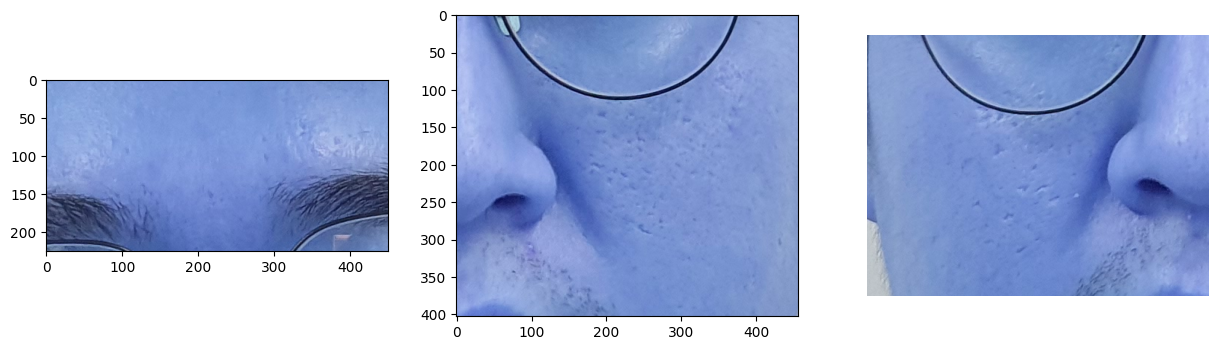

In [3]:
from tmp.crop_data import crop_cheeks_and_forehead_from_image
import os
import cv2
import matplotlib.pyplot as plt

forehead, left_cheek, right_cheek = crop_cheeks_and_forehead_from_image('/home/work/hocheol_dir/workspace/data/0000_CRS_19_01.jpg')

fig, ax = plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(forehead)
ax[1].imshow(left_cheek)
ax[2].imshow(right_cheek)

plt.axis('off')

plt.show()

In [4]:
import pandas as pd
labeled_df = pd.read_csv('/home/work/hocheol_dir/workspace/data/092_data/emotion_list_0511.csv')
labeled_df.head()

,filename,id,sex,age_group,left_cheek,right_cheek
0,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0
1,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0
2,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0
3,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0
4,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0


In [5]:
labeled_df.loc[0, 'filename']

'006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d_여_20_중립_공공시설&종교&의료시설_20210130215826-001-001.jpg'

In [6]:
labeled_df.loc[0, 'id']

'006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d'

In [7]:
import json
root_dir = '/home/work/hocheol_dir/workspace/data/092_data/092_origin_data'

data1 = []
data2 = []

for root, dirs, files in os.walk(root_dir):
    for file in files:
        if not file.lower().endswith('.json'):
            data1.append({'filename': file, 'path': os.path.join(root, file)})
        if file.lower().endswith('.jpg'):
            data2.append({'filename': file, 'path': os.path.join(root, file)})

path_df = pd.DataFrame(data1)

In [8]:
merged_df = pd.merge(labeled_df, path_df, how='left', on='filename')
merged_df.head()

,filename,id,sex,age_group,left_cheek,right_cheek,path
0,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0,/home/work/hocheol_dir/workspace/data/092_data...
1,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0,/home/work/hocheol_dir/workspace/data/092_data...
2,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0,/home/work/hocheol_dir/workspace/data/092_data...
3,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0,/home/work/hocheol_dir/workspace/data/092_data...
4,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0,/home/work/hocheol_dir/workspace/data/092_data...


In [9]:
# id 폴더 안에 left_cheek, right_cheek, forehead 만들자

In [9]:
merged_data = merged_df.to_dict(orient='records')
merged_data[0]

{'filename': '006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d_여_20_중립_공공시설&종교&의료시설_20210130215826-001-001.jpg',
 'id': '006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d',
 'sex': '여',
 'age_group': 20,
 'left_cheek': 1.0,
 'right_cheek': 0.0,
 'path': '/home/work/hocheol_dir/workspace/data/092_data/092_origin_data/[원천]EMOIMG_중립_TRAIN_01/006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d_여_20_중립_공공시설&종교&의료시설_20210130215826-001-001.jpg'}

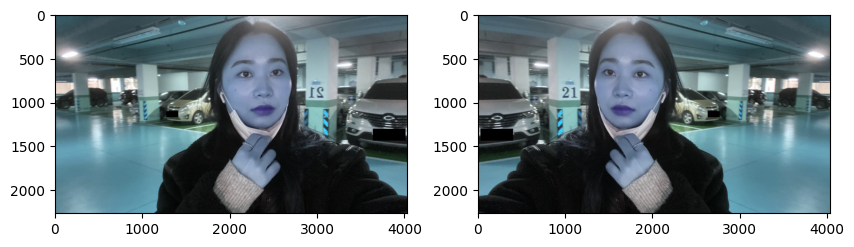

In [11]:
import matplotlib.pyplot as plt
import cv2

target_dir = '/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data'

for data in merged_data:
    origin_path = data['path']
    new_path = origin_path.replace('092_origin_data', '092_flipped_data')
    img = cv2.imread(origin_path)
    # flip img
    img2 = cv2.flip(img, 1)

    fig, ax = plt.subplots(1,2,figsize=(10,5))
    ax[0].imshow(img)
    ax[1].imshow(img2)
    plt.show()
    break

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
from tqdm import tqdm

target_dir = '/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data'

for data in tqdm(merged_data):
    origin_path = data['path']
    new_path = origin_path.replace('092_origin_data', '092_flipped_data')
    img = cv2.imread(origin_path)
    # flip img
    img2 = cv2.flip(img, 1)

    os.makedirs(os.path.dirname(new_path), exist_ok=True)
    cv2.imwrite(new_path, img2)

  0%|                                                                                                                         | 30/66636 [00:04<2:32:12,  7.29it/s]


KeyboardInterrupt: 

In [ ]:
import os
import cv2
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

target_dir = '/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data'

# 병렬로 처리할 함수 정의
def process_image(data):
    origin_path = data['path']
    new_path = origin_path.replace('092_origin_data', '092_flipped_data')
    
    img = cv2.imread(origin_path)
    if img is None:
        print(f"❗ 이미지 로딩 실패: {origin_path}")
        return
    
    # flip
    img2 = cv2.flip(img, 1)
    
    # 디렉토리 없으면 생성
    os.makedirs(os.path.dirname(new_path), exist_ok=True)
    
    # 저장
    cv2.imwrite(new_path, img2)

def parallel_process(merged_data, num_workers=None):
    if num_workers is None:
        num_workers = cpu_count()  # 최대 코어 사용

    with Pool(num_workers) as pool:
        list(tqdm(pool.imap_unordered(process_image, merged_data), total=len(merged_data)))

# 실행
parallel_process(merged_data)


  1%|▊                                                                                                                        | 431/66636 [00:05<09:09, 120.43it/s]Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
  1%|▊                                                                                                                         | 444/66636 [00:06<16:09, 68.28it/s]Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for se

In [14]:
import os
import cv2
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

# 병렬로 처리할 함수 정의
def process_image(data):
    if data['path'].lower().endswith('jpeg'):
        origin_path = data['path']
        new_path = origin_path.replace('092_origin_data', '092_flipped_data')
        
        img = cv2.imread(origin_path)
        if img is None:
            print(f"❗ 이미지 로딩 실패: {origin_path}")
            return
        
        os.makedirs(os.path.dirname(new_path), exist_ok=True)
        # flip
        # img2 = cv2.flip(img, 1)

        cv2.imwrite(new_path, img)

def parallel_process(merged_data, num_workers=None):
    if num_workers is None:
        num_workers = cpu_count()  # 최대 코어 사용

    with Pool(num_workers) as pool:
        list(tqdm(pool.imap_unordered(process_image, merged_data), total=len(merged_data)))

# 실행
parallel_process(merged_data)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 66636/66636 [00:12<00:00, 5238.43it/s]


In [10]:
merged_data[0]

{'filename': '006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d_여_20_중립_공공시설&종교&의료시설_20210130215826-001-001.jpg',
 'id': '006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d',
 'sex': '여',
 'age_group': 20,
 'left_cheek': 1.0,
 'right_cheek': 0.0,
 'path': '/home/work/hocheol_dir/workspace/data/092_data/092_origin_data/[원천]EMOIMG_중립_TRAIN_01/006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d_여_20_중립_공공시설&종교&의료시설_20210130215826-001-001.jpg'}

In [12]:
import os
import cv2
from tqdm import tqdm

new_data = []
target_dir = '/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data_crop'

for data in tqdm(merged_data):
    origin_path = data['path'].replace('092_origin_data', '092_flipped_data')
    id = data['id']

    left_cheek_path = os.path.join(target_dir, id, f'left_cheek_{data["filename"]}')
    right_cheek_path = os.path.join(target_dir, id, f'right_cheek_{data["filename"]}')
    forehead_path = os.path.join(target_dir, id, f'forehead_{data["filename"]}')

    if os.path.exists(left_cheek_path) and os.path.exists(right_cheek_path) and os.path.exists(forehead_path):
        new_data.append({**data,
                'left_cheek_path': left_cheek_path,
                'right_cheek_path': right_cheek_path,
                'forehead_path': forehead_path})
    else:
        os.makedirs(os.path.dirname(left_cheek_path), exist_ok=True)

        forehead, left_cheek, right_cheek = None, None, None
        try:
            forehead, left_cheek, right_cheek = crop_cheeks_and_forehead_from_image(origin_path)
        except Exception as e:
            print(f"❗ Crop 실패: {origin_path} | {e}")
            new_data.append({**data, 'fails':['forehead', 'left_cheek', 'right_cheek']})
            continue

        fault = []
        if forehead is None or forehead.size == 0:
            fault.append('forehead')
        if left_cheek is None or left_cheek.size == 0:
            fault.append('left_cheek')
        if right_cheek is None or right_cheek.size == 0:
            fault.append('right_cheek')
        
        if fault:
            print(f"❗ Crop 실패: {origin_path} | {fault}")
            new_data.append({**data, 'fails': fault})
        else:
            if not os.path.exists(left_cheek_path):
                cv2.imwrite(left_cheek_path, left_cheek)
            if not os.path.exists(right_cheek_path):
                cv2.imwrite(right_cheek_path, right_cheek)
            if not os.path.exists(forehead_path):
                cv2.imwrite(forehead_path, forehead)

            new_data.append({**data,
                    'left_cheek_path': left_cheek_path,
                    'right_cheek_path': right_cheek_path,
                    'forehead_path': forehead_path})

fails = [x for x in new_data if 'fails' in x]
print(f"\n⚠️ 총 실패한 데이터: {len(fails)}개")

  4%|████                                                                                                           | 2419/66636 [00:01<00:48, 1329.42it/s]W0000 00:00:1747480088.780025  941602 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747480088.791728  941606 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
  4%|████▌                                                                                                          | 2763/66636 [00:02<00:48, 1320.37it/s]

❗ Crop 실패: /home/work/hocheol_dir/workspace/data/092_data/092_flipped_data/[원천]EMOIMG_중립_VALID/0b33836b914f544c31e3a642ccccbb94114040537440b4df3b9250d025fc39a5_여_20_중립_숙박 및 거주공간_20210209152239-010-033.jpg | ['forehead']


  8%|████████▍                                                                                                      | 5093/66636 [00:03<00:46, 1328.58it/s]W0000 00:00:1747480090.683329  941699 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747480090.696695  941702 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
  8%|████████▊                                                                                                       | 5228/66636 [00:04<01:08, 891.17it/s]

❗ Crop 실패: /home/work/hocheol_dir/workspace/data/092_data/092_flipped_data/[원천]EMOIMG_중립_TRAIN_02/153a7db4cb4a1424137302d7d1bfa2f8a4fc3a84d210b36e8b0fa80689deb15f_여_30_중립_오락&공연시설_20210203062915-005-004.jpg | ['right_cheek']


  9%|██████████▎                                                                                                    | 6204/66636 [00:04<00:51, 1166.18it/s]W0000 00:00:1747480091.768416  941713 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747480091.780374  941721 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
 10%|██████████▊                                                                                                     | 6440/66636 [00:05<01:01, 974.38it/s]

...

❗ Crop 실패: /home/work/hocheol_dir/workspace/data/092_data/092_flipped_data/[원천]EMOIMG_중립_TRAIN_04/f8be8ba3cae84d34d2e6dd58c6ab7d1f0e1bb577010425a15cd04f6fbb122bd3_여_20_중립_숙박 및 거주공간_20210128142824-010-021.jpg | ['forehead']
❗ Crop 실패: /home/work/hocheol_dir/workspace/data/092_data/092_flipped_data/[원천]EMOIMG_중립_TRAIN_04/f8be8ba3cae84d34d2e6dd58c6ab7d1f0e1bb577010425a15cd04f6fbb122bd3_여_20_중립_숙박 및 거주공간_20210128142824-010-024.jpg | ['forehead']


W0000 00:00:1747480144.776913  943982 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747480144.797348  943985 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▋  | 65229/66636 [00:58<00:01, 950.10it/s]

❗ Crop 실패: /home/work/hocheol_dir/workspace/data/092_data/092_flipped_data/[원천]EMOIMG_중립_TRAIN_04/f94f3caa1541a613d1503bb15821fbf67e1e59200d2940b9c84ead934d9ff1e5_남_50_중립_숙박 및 거주공간_20210203135057-010-020.jpg | ['right_cheek']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 66503/66636 [00:59<00:00, 1191.50it/s]W0000 00:00:1747480146.088979  944006 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747480146.105998  944011 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 66636/66636 [00:59<00:00, 1121.01it/s]

❗ Crop 실패: /home/work/hocheol_dir/workspace/data/092_data/092_flipped_data/[원천]EMOIMG_중립_TRAIN_04/ffc31d193435ff87f522e2c47de67ee0fd87892903367e1099af837dbac20454_남_30_중립_교통&이동수단(엘리베이터 포함)_20210208104334-002-001.jpg | ['forehead']

⚠️ 총 실패한 데이터: 52개


In [22]:
new_data_df = pd.DataFrame(new_data)
new_data_df[new_data_df['fails'].notnull()]['fails'].value_counts()

fails
[forehead]                             40
[right_cheek]                          10
[forehead, left_cheek, right_cheek]     2
Name: count, dtype: int64

In [29]:
without_fails = new_data_df[new_data_df['fails'].isnull()].drop(columns=['fails', 'path'])
with open('/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data_crop.json', 'w') as f:
    json.dump(without_fails.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

In [13]:
# fails 저장
import pandas as pd

# fails 리스트를 DataFrame으로 변환
fails_df = pd.DataFrame(fails)

# 저장할 경로 (원하시는 경로로 바꿔도 됨)
fails_csv_path = '/home/work/hocheol_dir/workspace/data/092_data/092_crop_fails_list.csv'

# CSV로 저장
fails_df.to_csv(fails_csv_path, index=False, encoding='utf-8-sig')

print(f"\n✅ 실패한 데이터 {len(fails)}개를 '{fails_csv_path}' 에 저장했습니다.")



✅ 실패한 데이터 52개를 '/home/work/hocheol_dir/workspace/data/092_data/092_crop_fails_list.csv' 에 저장했습니다.


In [2]:
# label : 좌우 평균 반올림
# train, val, test split
import pandas as pd
import json
import os
from sklearn.model_selection import train_test_split

with open('/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data_crop.json', 'r') as f:
    json_df = pd.DataFrame(json.load(f))

In [ ]:
# 양이 즉다..
tmp_df = json_df.copy()
tmp_df.dropna(subset=['left_cheek', 'right_cheek'], inplace=True)
tmp_df['label'] = ((tmp_df['left_cheek'] + tmp_df['right_cheek']) / 2).round().astype(int)
tmp_df['user_id'] = tmp_df['id'].apply(lambda x: x.split('_')[0])
tmp_df.loc[:, ['user_id', 'label']][tmp_df['label'] != 6].drop_duplicates().value_counts('label')

label
0    163
1     42
2     29
3      2
4      1
Name: count, dtype: int64

In [2]:
# label(pigment class) 온몸 비틀기!!!!
# label을 양쪽의 평균 반올림하고 Nan은 Dataloader에서 빼는거로 하자
import pandas as pd
import json
with open('/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data_crop.json', 'r') as f:
    json_df = pd.DataFrame(json.load(f))

In [6]:
type(json_df[json_df['left_cheek'].isna()]['left_cheek'].values[0])

numpy.float64

In [7]:
import numpy as np
def get_label(row):
    if pd.isna(row['left_cheek']) or pd.isna(row['right_cheek']):
        return 6
    else:
        return int(round((row['left_cheek'] + row['right_cheek']) / 2))

json_df['label'] = json_df.apply(get_label, axis=1).astype(int)

In [14]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(json_df, groups=json_df['id']))

temp_df = json_df.iloc[train_idx].sort_values(by=['id']).reset_index(drop=True)
test_df = json_df.iloc[test_idx].sort_values(by=['id']).reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(gss2.split(temp_df, groups=temp_df['id']))

train_df = json_df.iloc[train_idx].sort_values(by=['id']).reset_index(drop=True)
val_df = json_df.iloc[val_idx].sort_values(by=['id']).reset_index(drop=True)

In [18]:
train_df['left_cheek_path'].values

array(['/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data_crop/006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d/left_cheek_006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d_여_20_중립_공공시설&종교&의료시설_20210130215826-001-001.jpg',
       '/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data_crop/006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d/left_cheek_006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d_여_20_중립_상업시설&점포&시장_20210130220011-003-005.jpg',
       '/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data_crop/006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d/left_cheek_006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d_여_20_중립_상업시설&점포&시장_20210130220011-003-006.jpg',
       ...,
       '/home/work/hocheol_dir/workspace/data/092_data/092_flipped_data_crop/e884e3bee913250e56fee74841c8f9aacdbea2c5e70df40352582e7300e39947/left_cheek_e884e3bee913250e56fee74841c8f9aacdb

In [29]:
root_dir = '/home/work/hocheol_dir/workspace/data'

train_df['new_left_cheek_path'] = train_df['left_cheek_path'].apply(lambda x:x.replace(root_dir+'/','').replace('092_flipped_data_crop', 'Training'))
train_df['new_right_cheek_path'] = train_df['right_cheek_path'].apply(lambda x:x.replace(root_dir+'/','').replace('092_flipped_data_crop', 'Training'))
train_df['new_forehead_path'] = train_df['forehead_path'].apply(lambda x:x.replace(root_dir+'/','').replace('092_flipped_data_crop', 'Training'))

val_df['new_left_cheek_path'] = val_df['left_cheek_path'].apply(lambda x:x.replace(root_dir+'/','').replace('092_flipped_data_crop', 'Validation'))
val_df['new_right_cheek_path'] = val_df['right_cheek_path'].apply(lambda x:x.replace(root_dir+'/','').replace('092_flipped_data_crop', 'Validation'))
val_df['new_forehead_path'] = val_df['forehead_path'].apply(lambda x:x.replace(root_dir+'/','').replace('092_flipped_data_crop', 'Validation'))

test_df['new_left_cheek_path'] = test_df['left_cheek_path'].apply(lambda x:x.replace(root_dir+'/','').replace('092_flipped_data_crop', 'Test'))
test_df['new_right_cheek_path'] = test_df['right_cheek_path'].apply(lambda x:x.replace(root_dir+'/','').replace('092_flipped_data_crop', 'Test'))
test_df['new_forehead_path'] = test_df['forehead_path'].apply(lambda x:x.replace(root_dir+'/','').replace('092_flipped_data_crop', 'Test'))

In [32]:
test_df.head(1)

,filename,id,sex,age_group,left_cheek,right_cheek,left_cheek_path,right_cheek_path,forehead_path,label,new_left_cheek_path,new_right_cheek_path,new_forehead_path
0,089c82e44335f55d5213966e8dc84395f730fed201ccc3...,089c82e44335f55d5213966e8dc84395f730fed201ccc3...,남,20,NaN,NaN,/home/work/hocheol_dir/workspace/data/092_data...,/home/work/hocheol_dir/workspace/data/092_data...,/home/work/hocheol_dir/workspace/data/092_data...,6,092_data/Test/089c82e44335f55d5213966e8dc84395...,092_data/Test/089c82e44335f55d5213966e8dc84395...,092_data/Test/089c82e44335f55d5213966e8dc84395...


In [33]:
import os
import shutil
from concurrent.futures import ThreadPoolExecutor

def copy_single_row(row, root_dir):
    # 디렉토리 생성
    os.makedirs(os.path.join(root_dir, os.path.dirname(row['new_left_cheek_path'])), exist_ok=True)
    os.makedirs(os.path.join(root_dir, os.path.dirname(row['new_right_cheek_path'])), exist_ok=True)
    os.makedirs(os.path.join(root_dir, os.path.dirname(row['new_forehead_path'])), exist_ok=True)

    # 파일 복사
    shutil.copy(row['left_cheek_path'], os.path.join(root_dir, row['new_left_cheek_path']))
    shutil.copy(row['right_cheek_path'], os.path.join(root_dir, row['new_right_cheek_path']))
    shutil.copy(row['forehead_path'], os.path.join(root_dir, row['new_forehead_path']))

def copy_files_parallel(df, root_dir, max_workers=50):
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(copy_single_row, row, root_dir) for _, row in df.iterrows()]
        for f in futures:
            f.result()  # 에러 발생 시 확인

# 사용 예시
copy_files_parallel(train_df, root_dir)
copy_files_parallel(val_df, root_dir)
copy_files_parallel(test_df, root_dir)


In [34]:
train_df['left_cheek_path'] = train_df['new_left_cheek_path']
train_df['right_cheek_path'] = train_df['new_right_cheek_path']
train_df['forehead_path'] = train_df['new_forehead_path']
train_df.drop(columns=['new_left_cheek_path', 'new_right_cheek_path', 'new_forehead_path'], inplace=True)

val_df['left_cheek_path'] = val_df['new_left_cheek_path']
val_df['right_cheek_path'] = val_df['new_right_cheek_path']
val_df['forehead_path'] = val_df['new_forehead_path']
val_df.drop(columns=['new_left_cheek_path', 'new_right_cheek_path', 'new_forehead_path'], inplace=True)

test_df['left_cheek_path'] = test_df['new_left_cheek_path']
test_df['right_cheek_path'] = test_df['new_right_cheek_path']
test_df['forehead_path'] = test_df['new_forehead_path']
test_df.drop(columns=['new_left_cheek_path', 'new_right_cheek_path', 'new_forehead_path'], inplace=True)

In [35]:
train_df

,filename,id,sex,age_group,left_cheek,right_cheek,left_cheek_path,right_cheek_path,forehead_path,label
0,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0,092_data/Training/006b56dc2f8cda2361e1b01b2496...,092_data/Training/006b56dc2f8cda2361e1b01b2496...,092_data/Training/006b56dc2f8cda2361e1b01b2496...,0
1,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0,092_data/Training/006b56dc2f8cda2361e1b01b2496...,092_data/Training/006b56dc2f8cda2361e1b01b2496...,092_data/Training/006b56dc2f8cda2361e1b01b2496...,0
2,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0,092_data/Training/006b56dc2f8cda2361e1b01b2496...,092_data/Training/006b56dc2f8cda2361e1b01b2496...,092_data/Training/006b56dc2f8cda2361e1b01b2496...,0
3,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0,092_data/Training/006b56dc2f8cda2361e1b01b2496...,092_data/Training/006b56dc2f8cda2361e1b01b2496...,092_data/Training/006b56dc2f8cda2361e1b01b2496...,0
4,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,여,20,1.0,0.0,092_data/Training/006b56dc2f8cda2361e1b01b2496...,092_data/Training/006b56dc2f8cda2361e1b01b2496...,092_data/Training/006b56dc2f8cda2361e1b01b2496...,0
...,...,...,...,...,...,...,...,...,...,...
53980,e884e3bee913250e56fee74841c8f9aacdbea2c5e70df4...,e884e3bee913250e56fee74841c8f9aacdbea2c5e70df4...,남,20,NaN,NaN,092_data/Training/e884e3bee913250e56fee74841c8...,092_data/Training/e884e3bee913250e56fee74841c8...,092_data/Training/e884e3bee913250e56fee74841c8...,6
53981,e884e3bee913250e56fee74841c8f9aacdbea2c5e70df4...,e884e3bee913250e56fee74841c8f9aacdbea2c5e70df4...,남,20,NaN,NaN,092_data/Training/e884e3bee913250e56fee74841c8...,092_data/Training/e884e3bee913250e56fee74841c8...,092_data/Training/e884e3bee913250e56fee74841c8...,6
53982,e884e3bee913250e56fee74841c8f9aacdbea2c5e70df4...,e884e3bee913250e56fee74841c8f9aacdbea2c5e70df4...,남,20,NaN,NaN,092_data/Training/e884e3bee913250e56fee74841c8...,092_data/Training/e884e3bee913250e56fee74841c8...,092_data/Training/e884e3bee913250e56fee74841c8...,6
53983,e884e3bee913250e56fee74841c8f9aacdbea2c5e70df4...,e884e3bee913250e56fee74841c8f9aacdbea2c5e70df4...,남,20,NaN,NaN,092_data/Training/e884e3bee913250e56fee74841c8...,092_data/Training/e884e3bee913250e56fee74841c8...,092_data/Training/e884e3bee913250e56fee74841c8...,6


In [36]:
new_json_root = '/home/work/hocheol_dir/workspace/data/092_data'

with open(os.path.join(new_json_root, 'train.json'), 'w') as f:
    json.dump(train_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(new_json_root, 'val.json'), 'w') as f:
    json.dump(val_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(new_json_root, 'test.json'), 'w') as f:
    json.dump(test_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)